In [1]:
import numpy as np
import pandas as pd 
import json
from hbv_bmi_project import HBV_Bmi
import xarray as xr

In [2]:
df = pd.read_csv("ERA5_Temp_1980_2026.csv")

# Parse year and month from the index (format: YYYYMM)
df['year'] = df['system:index'].astype(str).str[:4].astype(int)
df['month'] = df['system:index'].astype(str).str[4:6].astype(int)
 
# Convert temperature from Kelvin to Celsius
df['temperature_C'] = df['temperature_2m'] - 273.15
 
# Calculate mean annual temperature (average all months per year)
annual_mean = df.groupby('year')['temperature_C'].mean()
 
# Assign each year to a decade (e.g., 1980-1989 → 1980s)
annual_mean_df = annual_mean.reset_index()
annual_mean_df.columns = ['year', 'mean_annual_temp_C']
annual_mean_df['decade'] = (annual_mean_df['year'] // 10) * 10
 
# Calculate mean temperature per decade
decadal_mean = annual_mean_df.groupby('decade')['mean_annual_temp_C'].mean().reset_index()
decadal_mean.columns = ['decade', 'mean_decadal_temp_C']
 
print("Mean Annual Temperature per Year:")
print(annual_mean_df.to_string(index=False))
print("\nMean Temperature per Decade:")
print(decadal_mean.to_string(index=False))
 
# Pivot table: rows = years, columns = months (Jan=1 ... Dec=12)
pivot = df.pivot_table(index='year', columns='month', values='temperature_C')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot.index.name = 'year'
 
#print("\nMonthly Mean Temperature per Year (°C):")
#print(pivot.round(2).to_string())

Mean Annual Temperature per Year:
 year  mean_annual_temp_C  decade
 1980            7.973034    1980
 1981            8.474816    1980
 1982            9.249956    1980
 1983            9.250297    1980
 1984            8.350761    1980
 1985            7.820802    1980
 1986            8.149693    1980
 1987            8.072648    1980
 1988            9.459149    1980
 1989            9.858341    1980
 1990            9.866679    1990
 1991            8.950346    1990
 1992            9.638510    1990
 1993            9.042281    1990
 1994           10.184077    1990
 1995            9.518560    1990
 1996            7.946916    1990
 1997            9.287314    1990
 1998            9.076644    1990
 1999            9.614176    1990
 2000            9.938774    2000
 2001            9.376367    2000
 2002            9.934531    2000
 2003           10.092163    2000
 2004            9.192590    2000
 2005            9.413167    2000
 2006            9.978638    2000
 2007         

In [3]:
# Extract monthly mean temperatures for 1980-2020 as a 1D array
temp_1980_2020 = pivot.loc[1980:2020].values.flatten()
print(f"Monthly temperature array shape: {temp_1980_2020.shape}")
print(f"First 12 values (Jan-Dec 1980): {temp_1980_2020[:12]}")
print(f"Last 12 values (Jan-Dec 2020): {temp_1980_2020[-12:]}")
print(f"\nArray: {temp_1980_2020}")


Monthly temperature array shape: (492,)
First 12 values (Jan-Dec 1980): [-1.00103054  3.84723186  4.62921448  6.30690846 10.86167125 13.82727167
 14.54344663 16.57418022 14.6393308   8.34936158  2.92144297  0.1773746 ]
Last 12 values (Jan-Dec 2020): [ 3.78641294  5.46021825  5.75547273 11.80409456 13.20353548 16.61906182
 18.95159186 21.13463737 16.77357425 10.36604547  7.02498276  3.91438601]

Array: [-1.00103054e+00  3.84723186e+00  4.62921448e+00  6.30690846e+00
  1.08616712e+01  1.38272717e+01  1.45434466e+01  1.65741802e+01
  1.46393308e+01  8.34936158e+00  2.92144297e+00  1.77374602e-01
 -6.54509796e-01 -1.31626752e-02  7.38500702e+00  8.44216969e+00
  1.21274618e+01  1.44612798e+01  1.60168384e+01  1.67198913e+01
  1.43578249e+01  8.51588738e+00  4.72657892e+00 -3.87469909e-01
 -7.20549083e-01  1.76030182e+00  4.25276828e+00  6.68601671e+00
  1.22143833e+01  1.63491445e+01  1.90099002e+01  1.65793372e+01
  1.63404212e+01  9.62939805e+00  6.51466287e+00  2.38368600e+00
  3.447391

In [4]:
grdc_obs = pd.read_csv(
    "/Users/doriswong/Documents/ENVM1502/teaching-materials/Assignments/6336500_Q_Day.Cmd.txt",
    encoding="latin-1",
    sep=";",
    skiprows=36,
    index_col=0,
    parse_dates=True,
    usecols=[0, 2],
)
grdc_obs.index.name = "date"
grdc_obs.columns = ["Observations from GRDC"]

print(grdc_obs)

shape_area = 28191724718

            Observations from GRDC
date                              
1930-12-07                   415.0
1930-12-08                   388.0
1930-12-09                   378.0
1930-12-10                   391.0
1930-12-11                   388.0
...                            ...
2020-12-27                   568.0
2020-12-28                   663.0
2020-12-29                   698.0
2020-12-30                   729.0
2020-12-31                   636.0

[32898 rows x 1 columns]


In [5]:
# Load precipitation and evaporation monthly data
precip_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_precip_1980-01-01_2026-02-28.csv")
evap_df = pd.read_csv("/Users/doriswong/Documents/ENVM1502/teaching-materials/Main_project/Moselle_ERA5_monthly_evap_1980-01-01_2026-02-28.csv")

# Parse the system:index column (YYYYMM format) and filter to 1980-2020
precip_df['yyyymm'] = precip_df['system:index']
precip_df = precip_df[(precip_df['yyyymm'] >= 198001) & (precip_df['yyyymm'] <= 202012)].reset_index(drop=True)

evap_df['yyyymm'] = evap_df['system:index']
evap_df = evap_df[(evap_df['yyyymm'] >= 198001) & (evap_df['yyyymm'] <= 202012)].reset_index(drop=True)

# Create monthly date index for 1980-2020 (Jan 1980 to Dec 2020)
date_range_monthly = pd.date_range(start='1980-01-01', end='2020-12-31', freq='MS')

# Aggregate daily discharge observations to monthly mean
grdc_monthly = grdc_obs.copy()
grdc_monthly['year'] = grdc_monthly.index.year
grdc_monthly['month'] = grdc_monthly.index.month
discharge_monthly = grdc_monthly.groupby(['year', 'month'])['Observations from GRDC'].mean().reset_index()
discharge_monthly['date'] = pd.to_datetime(discharge_monthly[['year', 'month']].assign(day=1))
discharge_monthly = discharge_monthly[(discharge_monthly['year'] >= 1980) & (discharge_monthly['year'] <= 2020)].sort_values('date').reset_index(drop=True)

# Create the combined monthly dataframe
monthly_df = pd.DataFrame({
    'Date': date_range_monthly.values,
    'precipitation': precip_df['total_precipitation_sum'].values,
    'evaporation': evap_df[evap_df.columns[1]].values,  # Get the second column (evaporation values)
    'temperature': temp_1980_2020,
    'discharge': discharge_monthly['Observations from GRDC'].values,
    'delT': temp_1980_2020 - np.mean(temp_1980_2020)
})

print("Monthly DataFrame (1980-2020):")
print(monthly_df.head(12))
print(f"\nShape: {monthly_df.shape}")
#print(f"\nColumn dtypes:\n{monthly_df.dtypes}")
#print(f"\nSummary statistics:\n{monthly_df.describe()}")

Monthly DataFrame (1980-2020):
         Date  precipitation  evaporation  temperature   discharge       delT
0  1980-01-01       0.077218    -0.006487    -1.001031  592.322581 -10.451440
1  1980-02-01       0.081914    -0.021555     3.847232  896.241379  -5.603177
2  1980-03-01       0.089754    -0.037676     4.629214  269.935484  -4.821195
3  1980-04-01       0.060644    -0.064560     6.306908  293.433333  -3.143501
4  1980-05-01       0.073371    -0.092885    10.861671  180.354839   1.411262
5  1980-06-01       0.123058    -0.089279    13.827272  166.233333   4.376863
6  1980-07-01       0.144232    -0.083601    14.543447  582.290323   5.093038
7  1980-08-01       0.100759    -0.084409    16.574180  194.806452   7.123771
8  1980-09-01       0.040687    -0.060524    14.639331  135.933333   5.188922
9  1980-10-01       0.080884    -0.034231     8.349362  213.000000  -1.101047
10 1980-11-01       0.068660    -0.015680     2.921443  261.466667  -6.528966
11 1980-12-01       0.091563    -

In [6]:
growing_season_mask = (monthly_df['Date'].dt.month >= 4) & (monthly_df['Date'].dt.month <= 10)
monthly_df_growing = monthly_df[growing_season_mask].copy()
mean_temp = np.mean(monthly_df_growing['temperature'])
monthly_df_growing['delT'] = monthly_df_growing['temperature'] - mean_temp
print(monthly_df_growing.head())

        Date  precipitation  evaporation  temperature   discharge      delT
3 1980-04-01       0.060644    -0.064560     6.306908  293.433333 -7.668838
4 1980-05-01       0.073371    -0.092885    10.861671  180.354839 -3.114075
5 1980-06-01       0.123058    -0.089279    13.827272  166.233333 -0.148475
6 1980-07-01       0.144232    -0.083601    14.543447  582.290323  0.567700
7 1980-08-01       0.100759    -0.084409    16.574180  194.806452  2.598434


In [7]:
# Unit check and conversion for HBV inputs (model-ready)
check_df = monthly_df.copy()
check_df['days_in_month'] = check_df['Date'].dt.days_in_month

# ERA5 monthly totals are in meters of water; convert to mm/month
check_df['precip_mm_month'] = check_df['precipitation'] * 1000.0

# ERA5 evaporation is typically negative downward flux; use positive PET demand
check_df['pet_mm_month'] = (-check_df['evaporation']).clip(lower=0) * 1000.0

# HBV wrapper works with rate input and multiplies by dt internally, so use mm/day
check_df['precip_mm_day'] = check_df['precip_mm_month'] / check_df['days_in_month']
check_df['pet_mm_day'] = check_df['pet_mm_month'] / check_df['days_in_month']

# GRDC discharge is m3/s; convert to catchment-depth equivalent mm/day for NSE vs model Q
check_df['q_obs_mm_day'] = check_df['discharge'] * 86400.0 / shape_area * 1000.0

print('Unit check summary:')
print(check_df[['precipitation', 'evaporation', 'discharge']].describe())
print('\nConverted (use these for MC):')
print(check_df[['Date', 'precip_mm_day', 'pet_mm_day', 'q_obs_mm_day']].head(12))

# Optional arrays for the MC cell
precip_array = check_df['precip_mm_day'].to_numpy()
evap_array = check_df['pet_mm_day'].to_numpy()
temp_array = check_df['delT'].to_numpy()
q_obs_array = check_df['q_obs_mm_day'].to_numpy()
print(f'\nArray lengths -> P:{len(precip_array)}, EP:{len(evap_array)}, T:{len(temp_array)}, Qobs:{len(q_obs_array)}')

Unit check summary:
       precipitation  evaporation    discharge
count     492.000000   492.000000   492.000000
mean        0.080868    -0.053835   289.488208
std         0.036934     0.035737   239.251593
min         0.003944    -0.129790    43.419355
25%         0.055311    -0.087814   108.678226
50%         0.076800    -0.048791   205.790323
75%         0.101641    -0.018050   403.473214
max         0.231005    -0.002340  1223.387097

Converted (use these for MC):
         Date  precip_mm_day  pet_mm_day  q_obs_mm_day
0  1980-01-01       2.490905    0.209264      1.815308
1  1980-02-01       2.824620    0.743260      2.746737
2  1980-03-01       2.895305    1.215366      0.827279
3  1980-04-01       2.021470    2.152004      0.899294
4  1980-05-01       2.366812    2.996306      0.552739
5  1980-06-01       4.101950    2.975972      0.509460
6  1980-07-01       4.652650    2.696813      1.784562
7  1980-08-01       3.250283    2.722882      0.597029
8  1980-09-01       1.356227   

In [35]:
# Can revise the max and min ranges later 
#                   Imax Ce   Sumax0 beta Pmax  Tlag  Kf    Ks   Gamma
ParMinn = np.array([0.0, 0.1, 50.0, 0.8, 0.01, 1.0, 0.01, 0.001, -0.03])
ParMaxn = np.array([4.0, 1.2, 600.0, 4, 0.15, 6.0, 0.06, 0.03,  0.03])
Sin = np.array([0,  100,  0,  5  ])

In [42]:
# Use growing-season monthly arrays prepared in the unit-conversion cell
if any(arr.size == 0 for arr in (precip_array, evap_array, temp_array, q_obs_array)):
    raise ValueError('Run the unit-conversion cell first to create growing-season arrays.')

# Use the real growing-season dates (Apr-Oct, 1980-2020), not a synthetic continuous timeline
time_index = pd.DatetimeIndex(check_df['Date'].values)

precip_da = xr.DataArray(precip_array, coords={'time': time_index}, dims=('time',), name='pr')
evap_da = xr.DataArray(evap_array, coords={'time': time_index}, dims=('time',), name='evspsblpot')
temp_da = xr.DataArray(temp_array, coords={'time': time_index}, dims=('time',), name='tas')
Q_obs = np.asarray(q_obs_array)

config = {
    'precipitation_file': precip_da,
    'potential_evaporation_file': evap_da,
    'temperature_file': temp_da,
    'T_baseline': 8.99,
    'initial_storage': '0.0,100.0,20.0,30.0',
}

# Spin-up for 3 growing seasons (Apr-Oct => 7 months per season)
spinup_steps = 3 * 7

print(f'Model setup ready. Steps: {len(time_index)}')
print(f'Date range: {time_index.min().date()} to {time_index.max().date()}')
print(f'Unique months in index: {sorted(pd.Index(time_index.month).unique().tolist())}')
print(f'Spin-up steps: {spinup_steps}')

Model setup ready. Steps: 492
Date range: 1980-01-01 to 2020-12-01
Unique months in index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Spin-up steps: 21


In [ ]:
def nse(obs, sim):
    """Nash-Sutcliffe Efficiency"""
    obs = np.asarray(obs, dtype=float)
    sim = np.asarray(sim, dtype=float)
    return 1 - (np.sum((obs - sim) ** 2) / np.sum((obs - np.mean(obs)) ** 2))

N = 1000 # Number of runs
results = []

for i in range(N):
    # 1. Select random parameters from ParMinn/ParMaxn
    p = np.random.uniform(ParMinn, ParMaxn)

    # 2. Initialize the model from in-memory forcing arrays
    model = HBV_Bmi()
    model.initialize(config)
    model.set_pars(p)

    # 3. Run the full time series
    sim_q = []
    while model.current_timestep < model.end_timestep:
        model.update()
        dest = np.array([0.0])
        model.get_value('Q', dest)
        sim_q.append(dest[0])

    sim_q = np.asarray(sim_q, dtype=float)

    # Skip unstable runs
    if (not np.all(np.isfinite(sim_q))) or np.any(sim_q < 0):
        continue

    # 4. Score excluding warm-up period
    score = nse(Q_obs[spinup_steps:], sim_q[spinup_steps:])
    if np.isfinite(score):
        results.append((score, p))

if not results:
    raise RuntimeError('No stable Monte Carlo runs were found. Try narrowing parameter bounds.')

# Find the best parameter set
best_run = max(results, key=lambda x: x[0])
print(f'Best NSE (post spin-up): {best_run[0]}')
print(f'Best Parameters: {best_run[1]}')
print(f'Accepted stable runs: {len(results)} / {N}')

Best NSE (post spin-up): -0.14730025569672422
Best Parameters: [ 3.17019572e+00  1.16966638e-01  4.86414593e+02  2.82343767e+00
  4.35275494e-02  4.78840887e+00  2.14744653e-02  2.84366256e-02
 -2.20415388e-02]
Accepted stable runs: 1000 / 1000


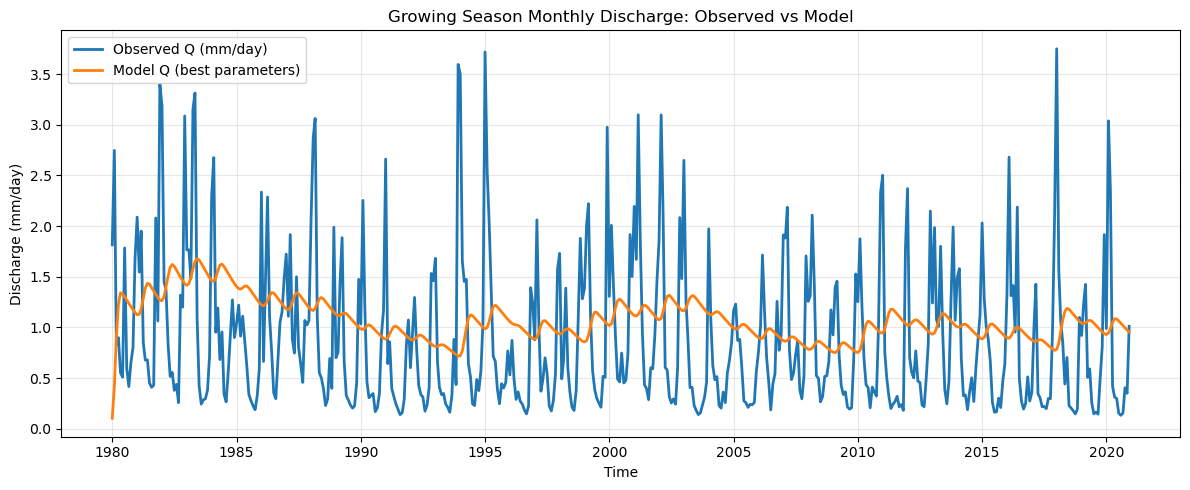

Best NSE: -0.1473


In [44]:
import matplotlib.pyplot as plt

# Re-run model with the best parameter set to get the full simulated Q series
best_params = best_run[1]
plot_model = HBV_Bmi()
plot_model.initialize(config)
plot_model.set_pars(best_params)

best_sim_q = []
while plot_model.current_timestep < plot_model.end_timestep:
    plot_model.update()
    q_dest = np.array([0.0])
    plot_model.get_value('Q', q_dest)
    best_sim_q.append(q_dest[0])

best_sim_q = np.asarray(best_sim_q)

plt.figure(figsize=(12, 5))
plt.plot(time_index, Q_obs, label='Observed Q (mm/day)', linewidth=2)
plt.plot(time_index, best_sim_q, label='Model Q (best parameters)', linewidth=2)
plt.title('Growing Season Monthly Discharge: Observed vs Model')
plt.xlabel('Time')
plt.ylabel('Discharge (mm/day)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best NSE: {best_run[0]:.4f}')

In [45]:
df_new = pd.DataFrame({
    'time': time_index,
    'obs_q': Q_obs,
    'model_q': best_sim_q,
})
print(df_new.head(12))
print(df_new.tail(12))
print(f"Rows: {len(df_new)} | Date range: {df_new['time'].min().date()} to {df_new['time'].max().date()}")
print(f"Months present: {sorted(df_new['time'].dt.month.unique().tolist())}")

         time     obs_q   model_q
0  1980-01-01  1.815308  0.104098
1  1980-02-01  2.746737  0.419495
2  1980-03-01  0.827279  0.899206
3  1980-04-01  0.899294  1.229150
4  1980-05-01  0.552739  1.342055
5  1980-06-01  0.509460  1.330288
6  1980-07-01  1.784562  1.302776
7  1980-08-01  0.597029  1.270094
8  1980-09-01  0.416599  1.237670
9  1980-10-01  0.652787  1.206095
10 1980-11-01  0.801325  1.175425
11 1980-12-01  1.683624  1.146500
          time     obs_q   model_q
480 2020-01-01  0.989611  0.929585
481 2020-02-01  3.038098  0.944242
482 2020-03-01  2.335225  0.990196
483 2020-04-01  0.418846  1.051141
484 2020-05-01  0.314283  1.085449
485 2020-06-01  0.298300  1.084185
486 2020-07-01  0.153434  1.063758
487 2020-08-01  0.133069  1.040896
488 2020-09-01  0.154667  1.018513
489 2020-10-01  0.404663  0.996631
490 2020-11-01  0.350911  0.975302
491 2020-12-01  1.011657  0.954894
Rows: 492 | Date range: 1980-01-01 to 2020-12-01
Months present: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12

In [46]:
pd.set_option('display.max_rows', None)
print(df_new.to_string(index=False))
pd.reset_option('display.max_rows')

      time    obs_q  model_q
1980-01-01 1.815308 0.104098
1980-02-01 2.746737 0.419495
1980-03-01 0.827279 0.899206
1980-04-01 0.899294 1.229150
1980-05-01 0.552739 1.342055
1980-06-01 0.509460 1.330288
1980-07-01 1.784562 1.302776
1980-08-01 0.597029 1.270094
1980-09-01 0.416599 1.237670
1980-10-01 0.652787 1.206095
1980-11-01 0.801325 1.175425
1980-12-01 1.683624 1.146500
1981-01-01 2.088662 1.126139
1981-02-01 1.546594 1.129605
1981-03-01 1.951046 1.182837
1981-04-01 0.850564 1.284018
1981-05-01 0.677602 1.390039
1981-06-01 0.680370 1.436320
1981-07-01 0.452987 1.426402
1981-08-01 0.409487 1.392947
1981-09-01 0.429981 1.359380
1981-10-01 2.080457 1.326649
1981-11-01 1.063972 1.295108
1981-12-01 3.399674 1.267710
1982-01-01 3.189988 1.263928
1982-02-01 1.444801 1.304599
1982-03-01 1.375272 1.397652
1982-04-01 0.831665 1.505517
1982-05-01 0.516654 1.593382
1982-06-01 0.556248 1.621222
1982-07-01 0.379928 1.603594
1982-08-01 0.438256 1.566821
1982-09-01 0.258357 1.530574
1982-10-01 1.3

In [50]:
print('delT range:', float(check_df['delT'].min()), float(check_df['delT'].max()))
print('precip_mm_day range:', float(check_df['precip_mm_day'].min()), float(check_df['precip_mm_day'].max()))
print('pet_mm_day range:', float(check_df['pet_mm_day'].min()), float(check_df['pet_mm_day'].max()))

delT range: -14.850176799455765 13.350346258207027
precip_mm_day range: 0.13147988257990667 7.451758367206206
pet_mm_day range: 0.07546922346555807 4.3263222137263995


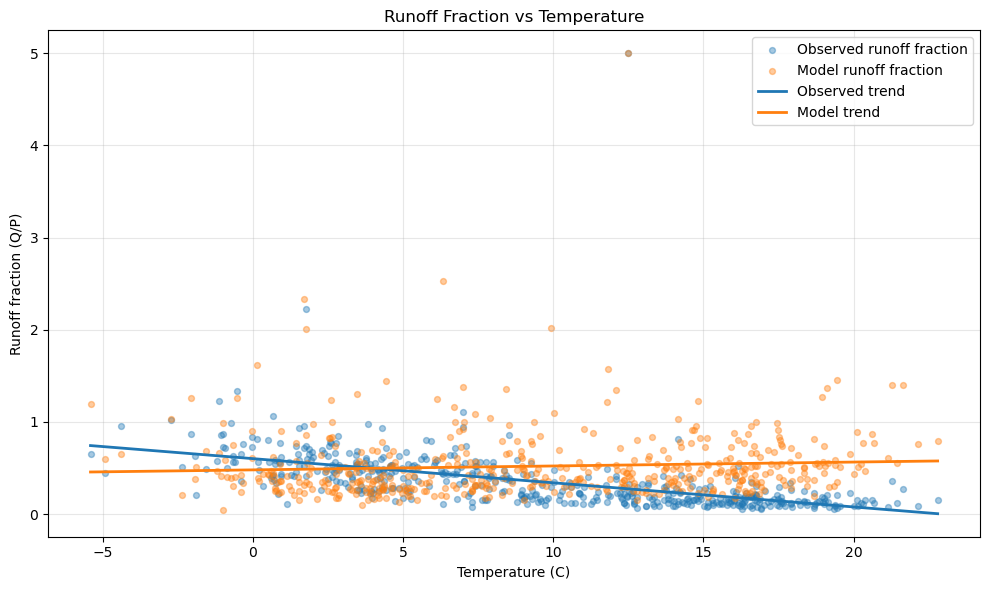

Observed trend slope: -0.0262 per C
Model trend slope:    0.0042 per C


In [48]:
import matplotlib.pyplot as plt

# Quick hypothesis check: runoff fraction vs temperature
# Runoff fraction here is Q/P (both in mm/day).
rf_df = check_df.copy()
rf_df = rf_df[rf_df['precip_mm_day'] > 0.1].copy()
rf_df['runoff_fraction_obs'] = rf_df['q_obs_mm_day'] / rf_df['precip_mm_day']
rf_df['runoff_fraction_model'] = best_sim_q / rf_df['precip_mm_day']

# Keep extreme outliers from dominating the visual check
rf_df['runoff_fraction_obs'] = rf_df['runoff_fraction_obs'].clip(upper=5)
rf_df['runoff_fraction_model'] = rf_df['runoff_fraction_model'].clip(upper=5)

x = rf_df['temperature'].to_numpy()
y_obs = rf_df['runoff_fraction_obs'].to_numpy()
y_mod = rf_df['runoff_fraction_model'].to_numpy()

obs_fit = np.polyfit(x, y_obs, 1)
mod_fit = np.polyfit(x, y_mod, 1)
obs_line = np.poly1d(obs_fit)
mod_line = np.poly1d(mod_fit)

plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, alpha=0.4, s=18, label='Observed runoff fraction')
plt.scatter(x, y_mod, alpha=0.4, s=18, label='Model runoff fraction')

x_line = np.linspace(np.min(x), np.max(x), 200)
plt.plot(x_line, obs_line(x_line), linewidth=2, label='Observed trend')
plt.plot(x_line, mod_line(x_line), linewidth=2, label='Model trend')

plt.xlabel('Temperature (C)')
plt.ylabel('Runoff fraction (Q/P)')
plt.title('Runoff Fraction vs Temperature')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Observed trend slope: {obs_fit[0]:.4f} per C')
print(f'Model trend slope:    {mod_fit[0]:.4f} per C')

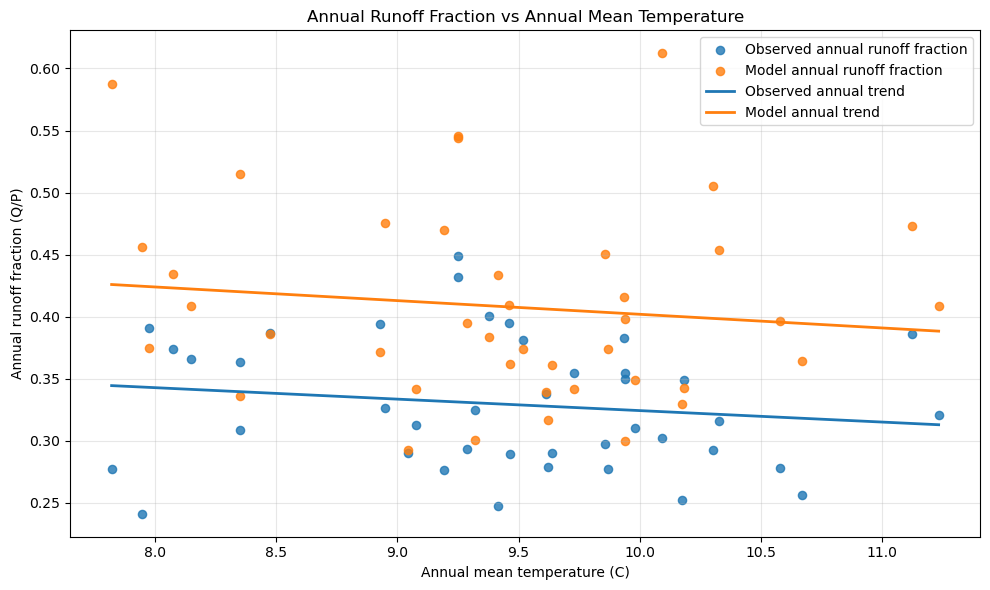

Observed annual slope: -0.0092 per C
Model annual slope:    -0.0110 per C
   year    temp_C    rf_obs    rf_mod
0  1980  7.973034  0.390967  0.374475
1  1981  8.474816  0.387067  0.385817
2  1982  9.249956  0.449185  0.545616
3  1983  9.250297  0.431927  0.544038
4  1984  8.350761  0.363454  0.514640


In [49]:
# Annual-scale relationship (reduces seasonal effects)
annual_df = check_df.copy()
annual_df = annual_df[['Date', 'temperature', 'precip_mm_day', 'q_obs_mm_day', 'days_in_month']].copy()
annual_df['year'] = annual_df['Date'].dt.year
annual_df['model_q_mm_day'] = best_sim_q

# Convert rates back to monthly depths before annual aggregation
annual_df['precip_mm_month'] = annual_df['precip_mm_day'] * annual_df['days_in_month']
annual_df['q_obs_mm_month'] = annual_df['q_obs_mm_day'] * annual_df['days_in_month']
annual_df['q_mod_mm_month'] = annual_df['model_q_mm_day'] * annual_df['days_in_month']

annual_agg = annual_df.groupby('year').agg(
    temp_C=('temperature', 'mean'),
    precip_mm=('precip_mm_month', 'sum'),
    q_obs_mm=('q_obs_mm_month', 'sum'),
    q_mod_mm=('q_mod_mm_month', 'sum')
).reset_index()

annual_agg = annual_agg[annual_agg['precip_mm'] > 1e-6].copy()
annual_agg['rf_obs'] = annual_agg['q_obs_mm'] / annual_agg['precip_mm']
annual_agg['rf_mod'] = annual_agg['q_mod_mm'] / annual_agg['precip_mm']

x = annual_agg['temp_C'].to_numpy()
y_obs = annual_agg['rf_obs'].to_numpy()
y_mod = annual_agg['rf_mod'].to_numpy()

obs_fit = np.polyfit(x, y_obs, 1)
mod_fit = np.polyfit(x, y_mod, 1)
obs_line = np.poly1d(obs_fit)
mod_line = np.poly1d(mod_fit)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x, y_obs, s=35, alpha=0.8, label='Observed annual runoff fraction')
plt.scatter(x, y_mod, s=35, alpha=0.8, label='Model annual runoff fraction')

x_line = np.linspace(np.min(x), np.max(x), 200)
plt.plot(x_line, obs_line(x_line), linewidth=2, label='Observed annual trend')
plt.plot(x_line, mod_line(x_line), linewidth=2, label='Model annual trend')

plt.xlabel('Annual mean temperature (C)')
plt.ylabel('Annual runoff fraction (Q/P)')
plt.title('Annual Runoff Fraction vs Annual Mean Temperature')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Observed annual slope: {obs_fit[0]:.4f} per C')
print(f'Model annual slope:    {mod_fit[0]:.4f} per C')
print(annual_agg[['year', 'temp_C', 'rf_obs', 'rf_mod']].head())

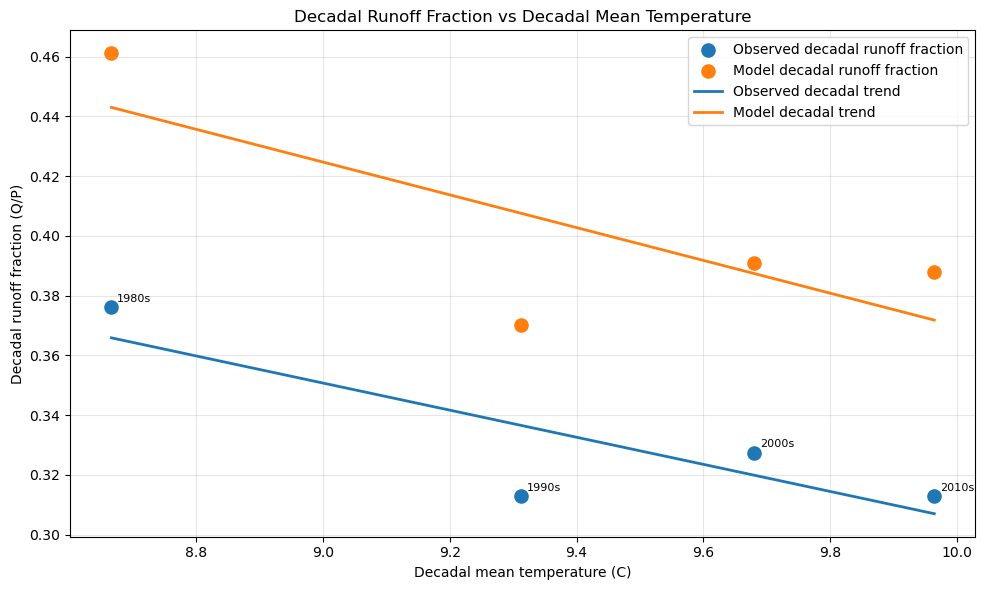

Observed decadal slope: -0.0454 per C
Model decadal slope:    -0.0549 per C
   decade    temp_C    rf_obs    rf_mod
0    1980  8.665950  0.376101  0.461118
1    1990  9.312550  0.312812  0.370016
2    2000  9.680561  0.327440  0.390801
3    2010  9.964332  0.312834  0.387812


In [52]:
# 10-year block analysis (decadal scale)
# Use annual aggregates, then average/sum into full decades.
decadal_source = annual_agg.copy()
decadal_source['decade'] = (decadal_source['year'] // 10) * 10

# Keep only full 10-year blocks so each point is comparable.
full_decades = decadal_source.groupby('decade')['year'].count()
full_decades = full_decades[full_decades >= 10].index

decadal_agg = decadal_source[decadal_source['decade'].isin(full_decades)].groupby('decade').agg(
    temp_C=('temp_C', 'mean'),
    precip_mm=('precip_mm', 'sum'),
    q_obs_mm=('q_obs_mm', 'sum'),
    q_mod_mm=('q_mod_mm', 'sum')
).reset_index()

decadal_agg['rf_obs'] = decadal_agg['q_obs_mm'] / decadal_agg['precip_mm']
decadal_agg['rf_mod'] = decadal_agg['q_mod_mm'] / decadal_agg['precip_mm']

x_dec = decadal_agg['temp_C'].to_numpy()
y_dec_obs = decadal_agg['rf_obs'].to_numpy()
y_dec_mod = decadal_agg['rf_mod'].to_numpy()

obs_fit_dec = np.polyfit(x_dec, y_dec_obs, 1)
mod_fit_dec = np.polyfit(x_dec, y_dec_mod, 1)
obs_line_dec = np.poly1d(obs_fit_dec)
mod_line_dec = np.poly1d(mod_fit_dec)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(x_dec, y_dec_obs, s=90, label='Observed decadal runoff fraction')
plt.scatter(x_dec, y_dec_mod, s=90, label='Model decadal runoff fraction')

x_line_dec = np.linspace(np.min(x_dec), np.max(x_dec), 200)
plt.plot(x_line_dec, obs_line_dec(x_line_dec), linewidth=2, label='Observed decadal trend')
plt.plot(x_line_dec, mod_line_dec(x_line_dec), linewidth=2, label='Model decadal trend')

for _, row in decadal_agg.iterrows():
    plt.annotate(f"{int(row['decade'])}s", (row['temp_C'], row['rf_obs']), textcoords='offset points', xytext=(4, 4), fontsize=8)

plt.xlabel('Decadal mean temperature (C)')
plt.ylabel('Decadal runoff fraction (Q/P)')
plt.title('Decadal Runoff Fraction vs Decadal Mean Temperature')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Observed decadal slope: {obs_fit_dec[0]:.4f} per C')
print(f'Model decadal slope:    {mod_fit_dec[0]:.4f} per C')
print(decadal_agg[['decade', 'temp_C', 'rf_obs', 'rf_mod']])

In [51]:
gamma_best = float(best_run[1][8])
print(f'Best Gamma: {gamma_best:.5f}')

# d(Su_max)/d(DelT) = Gamma in current model setup
if gamma_best < 0:
    print('Current best run follows hypothesis: higher temperature -> lower Su_max')
elif gamma_best > 0:
    print('Current best run opposes hypothesis: higher temperature -> higher Su_max')
else:
    print('Current best run has no temperature effect on Su_max (Gamma ~ 0)')

Best Gamma: -0.02204
Current best run follows hypothesis: higher temperature -> lower Su_max
